In [1]:
import torch as tc
import numpy as np
import qutip as qt
import function as my
import matplotlib.pyplot as plt
from tqdm import tqdm

class SIN(tc.nn.Module):
    def __init__(self): 
        super(SIN, self).__init__() 
    def forward(self, x):
        return tc.sin(x)
    
# ─────────────────────────────────────────────
# Campos externos dependentes do tempo
# ─────────────────────────────────────────────

def field_oscillatory(t, args=None):
    """Campo oscilatório multi-frequência com envelope senoidal."""
    envelope = np.sin(np.pi * t / tfinal) ** 2
    return (1.5 * np.sin(2.0 * t)
            - 0.3 * np.cos(3.0 * t - 0.5)
            + 0.4 * np.sin(7.0 * t)) * envelope


def field_gaussian(t, args=None):
    """Pulso gaussiano centrado no meio da evolução."""
    t0    = tfinal / 2.0
    sigma = tfinal / 8.0
    amp   = 2.0
    return amp * np.exp(-0.5 * ((t - t0) / sigma) ** 2)

def op3(A, B, C):
    return qt.tensor(A, B, C)

# ─────────────────────────────────────────────
# Hamiltoniana e simulação
# ─────────────────────────────────────────────

def build_H0(J12, J13, J23, omega1, omega2, omega3):
    """
    H0 = Σ ωi σiz/2  +  J12 σ1z σ2z  +  J13 σ1z σ3z  +  J23 σ2z σ3z
    Acoplamento tipo Ising ZZ com acoplamentos distintos por par.
    """
    # Termos de campo local (em z)
    H_loc = (omega1 * op3(sz, I,  I )
           + omega2 * op3(I,  sz, I )
           + omega3 * op3(I,  I,  sz))
    # Acoplamentos ZZ com parâmetros independentes
    H_zz  = (J12 * op3(sz, sz, I )
            + J13 * op3(sz, I,  sz)
            + J23 * op3(I,  sz, sz))
    return H_loc + H_zz


def build_c_ops(gm1, gm2, gm3, gp1, gp2, gp3):
    """Operadores de colapso de Lindblad para cada qubit."""
    c_ops = []
    # σ- = destroy  (relaxamento para |0⟩)
    if gm1 > 0: c_ops.append(np.sqrt(gm1) * op3(qt.destroy(2), I, I))
    if gm2 > 0: c_ops.append(np.sqrt(gm2) * op3(I, qt.destroy(2), I))
    if gm3 > 0: c_ops.append(np.sqrt(gm3) * op3(I, I, qt.destroy(2)))
    # σ+ = create   (excitação térmica)
    if gp1 > 0: c_ops.append(np.sqrt(gp1) * op3(qt.create(2), I, I))
    if gp2 > 0: c_ops.append(np.sqrt(gp2) * op3(I, qt.create(2), I))
    if gp3 > 0: c_ops.append(np.sqrt(gp3) * op3(I, I, qt.create(2)))
    return c_ops


def initial_state(theta=np.pi/4, phi=0.0):
    """Estado inicial: produto tensorial de estados de Bloch idênticos."""
    ket = (np.cos(theta) * qt.basis(2, 0)
         + np.sin(theta) * np.exp(1j * phi) * qt.basis(2, 1))
    return qt.tensor(ket, ket, ket)


def simulate_3qubits(
    O_op, tlist, field_func,
    J12=1.0, J13=0.8, J23=0.6,
    omega1=1.0, omega2=0.7, omega3=0.5,
    gamma_minus=(0.05, 0.03, 0.04),
    gamma_plus=(0.0,  0.0,  0.0),
    theta=np.pi/4, phi=0.0,
    field_qubit=1,        # qual qubit recebe o campo (1, 2 ou 3)
):
    """
    Simula a dinâmica de sistema quântico aberto para 3 qubits.

    Hamiltoniana:
        H(t) = H0 + B(t) * σx_qubit

        H0 = ω1 σ1z + ω2 σ2z + ω3 σ3z
           + J12 σ1z σ2z + J13 σ1z σ3z + J23 σ2z σ3z

    Parâmetros
    ----------
    field_func : callable  f(t) → float
    field_qubit : 1, 2 ou 3 — qubit que acopla ao campo externo (em σx)
    """
    H0 = build_H0(J12, J13, J23, omega1, omega2, omega3)

    # Operador de acoplamento ao campo (σx no qubit escolhido)
    H1_map = {
        1: op3(sx, I, I),
        2: op3(I, sx, I),
        3: op3(I, I, sx),
    }
    H1 = H1_map[field_qubit]

    # QuTiP aceita campo como lista de valores ou como [Qobj, func]
    H = [H0, [H1, field_func]]

    c_ops = build_c_ops(*gamma_minus, *gamma_plus)
    psi0  = initial_state(theta, phi)

    opts = qt.Options(nsteps=200000, atol=1e-12, rtol=1e-12)
    result = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op, options=opts)

    return np.array(result.expect)   # shape: (n_obs, n_times)


# Hamiltoniana de três qubits

![](hamiltoniana_3qubits.svg)

$$H(t) = \omega_1\sigma_1^z + \omega_2\sigma_2^z + \omega_3\sigma_3^z$$

$$\quad\; + J_{12}\sigma_1^z\sigma_2^z + J_{13}\sigma_1^z\sigma_3^z + J_{23}\sigma_2^z\sigma_3^z$$

$$\quad\; + B(t)\,\sigma_x^{(q)}$$

onde $B(t)$ representa o campo externo dependente do tempo aplicado ao qubit de interesse.

In [4]:
# ─────────────────────────────────────────────
# Parâmetros globais
# ─────────────────────────────────────────────
tfinal = 2*np.pi
N      = 100
tlist  = np.linspace(0.0, tfinal, N)

J12 = .5
J13 = .5
J23 = .5

omega1 = 1.0
omega2 = 1.0
omega3 = 1.0

gamma1_m = 0.00
gamma2_m = 0.00
gamma3_m = 0.00
gamma1_p = 0.00
gamma2_p = 0.00
gamma3_p = 0.00

Simulando com campo oscilatório...
Simulando com pulso gaussiano...


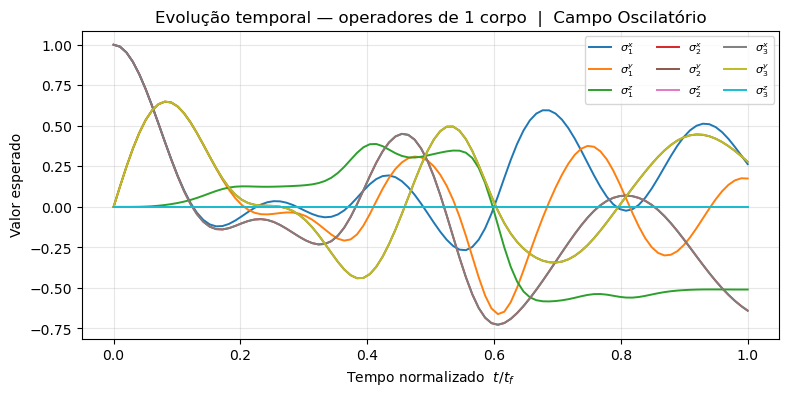

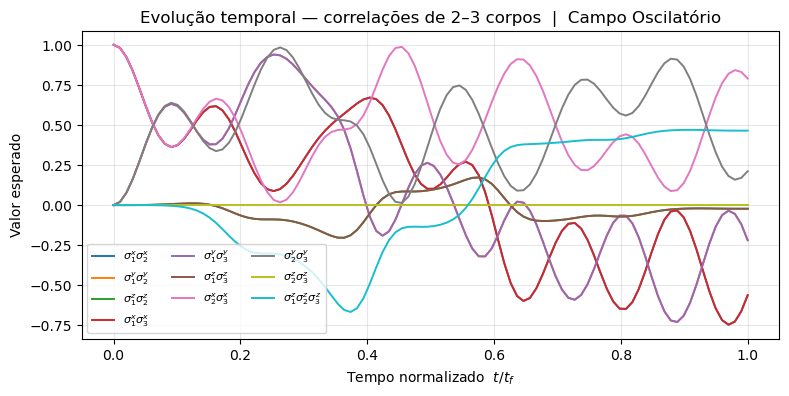

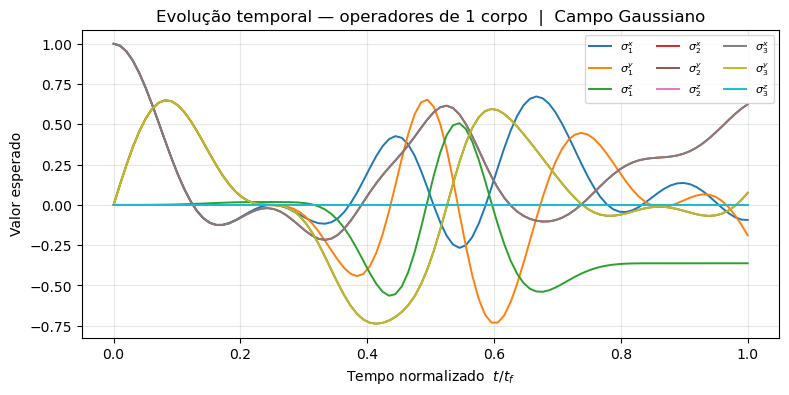

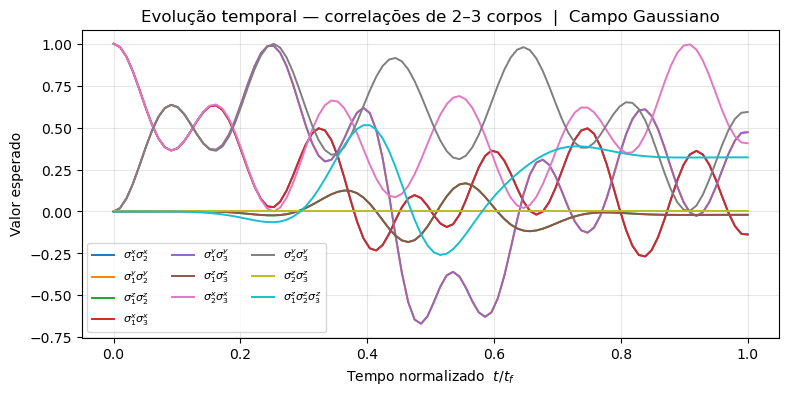

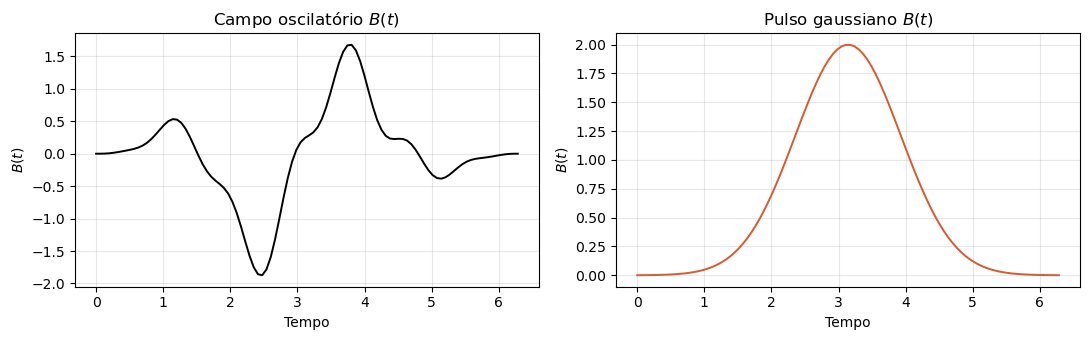

Concluído.


In [5]:
# ─────────────────────────────────────────────
# Operadores observáveis — 1-corpo (9), 2-corpo diagonal (9), 3-corpo (1)
# ─────────────────────────────────────────────
I  = qt.qeye(2)
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()

O_op = [
    op3(sx, I,  I ),   # 0  XII
    op3(sy, I,  I ),   # 1  YII
    op3(sz, I,  I ),   # 2  ZII
    op3(I,  sx, I ),   # 3  IXI
    op3(I,  sy, I ),   # 4  IYI
    op3(I,  sz, I ),   # 5  IZI
    op3(I,  I,  sx),   # 6  IIX
    op3(I,  I,  sy),   # 7  IIY
    op3(I,  I,  sz),   # 8  IIZ
    # 2-corpo — produtos diagonais de Pauli por par
    op3(sx, sx, I ),   # 9  XXI
    op3(sy, sy, I ),   # 10 YYI
    op3(sz, sz, I ),   # 11 ZZI
    op3(sx, I,  sx),   # 12 XIX
    op3(sy, I,  sy),   # 13 YIY
    op3(sz, I,  sz),   # 14 ZIZ
    op3(I,  sx, sx),   # 15 IXX
    op3(I,  sy, sy),   # 16 IYY
    op3(I,  sz, sz),   # 17 IZZ
    # 3-corpo
    op3(sz, sz, sz),   # 18 ZZZ
]

O_labels = [
    r"$\sigma_1^x$", r"$\sigma_1^y$", r"$\sigma_1^z$",
    r"$\sigma_2^x$", r"$\sigma_2^y$", r"$\sigma_2^z$",
    r"$\sigma_3^x$", r"$\sigma_3^y$", r"$\sigma_3^z$",
    r"$\sigma_1^x\sigma_2^x$", r"$\sigma_1^y\sigma_2^y$", r"$\sigma_1^z\sigma_2^z$",
    r"$\sigma_1^x\sigma_3^x$", r"$\sigma_1^y\sigma_3^y$", r"$\sigma_1^z\sigma_3^z$",
    r"$\sigma_2^x\sigma_3^x$", r"$\sigma_2^y\sigma_3^y$", r"$\sigma_2^z\sigma_3^z$",
    r"$\sigma_1^z\sigma_2^z\sigma_3^z$",
]

# ─────────────────────────────────────────────
# Execução — campo oscilatório e gaussiano
# ─────────────────────────────────────────────
print("Simulando com campo oscilatório...")
data_osc = simulate_3qubits(
    O_op, tlist, field_oscillatory,
    J12=J12, J13=J13, J23=J23,
    omega1=omega1, omega2=omega2, omega3=omega3,
    gamma_minus=(gamma1_m, gamma2_m, gamma3_m),
    gamma_plus =(gamma1_p, gamma2_p, gamma3_p),
    field_qubit=1,
)

print("Simulando com pulso gaussiano...")
data_gauss = simulate_3qubits(
    O_op, tlist, field_gaussian,
    J12=J12, J13=J13, J23=J23,
    omega1=omega1, omega2=omega2, omega3=omega3,
    gamma_minus=(gamma1_m, gamma2_m, gamma3_m),
    gamma_plus =(gamma1_p, gamma2_p, gamma3_p),
    field_qubit=1,
)

# ─────────────────────────────────────────────
# Plots
# ─────────────────────────────────────────────
t_norm = tlist / tfinal
colors_1body = plt.cm.tab10(np.linspace(0, 1, 9))
colors_2body = plt.cm.tab10(np.linspace(0, 1, len(O_op) - 9))

for field_label, data in [("Oscilatório", data_osc), ("Gaussiano", data_gauss)]:
    fig, ax = plt.subplots(figsize=(9, 4))
    for i in range(9):
        ax.plot(t_norm, data[i], label=O_labels[i], lw=1.4, color=colors_1body[i])
    ax.set_xlabel("Tempo normalizado  $t/t_f$")
    ax.set_ylabel("Valor esperado")
    ax.set_title(f"Evolução temporal — operadores de 1 corpo  |  Campo {field_label}")
    ax.legend(ncol=3, fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4))
    for i in range(9, len(O_op)):
        ax.plot(t_norm, data[i], label=O_labels[i], lw=1.4, color=colors_2body[i - 9])
    ax.set_xlabel("Tempo normalizado  $t/t_f$")
    ax.set_ylabel("Valor esperado")
    ax.set_title(f"Evolução temporal — correlações de 2–3 corpos  |  Campo {field_label}")
    ax.legend(ncol=3, fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(tlist, field_oscillatory(tlist), "k-", lw=1.4)
axes[0].set_title("Campo oscilatório $B(t)$")
axes[0].set_xlabel("Tempo")
axes[0].set_ylabel("$B(t)$")
axes[0].grid(alpha=0.3)

axes[1].plot(tlist, field_gaussian(tlist), color="#D85A30", lw=1.4)
axes[1].set_title("Pulso gaussiano $B(t)$")
axes[1].set_xlabel("Tempo")
axes[1].set_ylabel("$B(t)$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Concluído.")


In [ ]:
import torch as tc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ────────────────────────────────────────────────────────────────────
# Parâmetros físicos (herdados da célula anterior)
# ────────────────────────────────────────────────────────────────────
epocas = 10000
g1m = gamma1_m
g2m = gamma2_m
g3m = gamma3_m

# ────────────────────────────────────────────────────────────────────
# Dados de treinamento: mesma física, campo gaussiano
# simulate_3qubits retorna shape (n_obs, N) → transpor para (N, n_obs)
# ────────────────────────────────────────────────────────────────────
valor_esperado_data = simulate_3qubits(
    O_op, tlist, field_gaussian,
    J12=J12, J13=J13, J23=J23,
    omega1=omega1, omega2=omega2, omega3=omega3,
    gamma_minus=(gamma1_m, gamma2_m, gamma3_m),
    gamma_plus =(gamma1_p, gamma2_p, gamma3_p),
    field_qubit=1,
)
data_tensor = tc.tensor(valor_esperado_data.T, dtype=tc.float32)  # (N, n_obs)

# ────────────────────────────────────────────────────────────────────
# 63 observáveis Pauli não-identidade (sistema de EDOs fechado)
# ────────────────────────────────────────────────────────────────────
ordered = [
    # 1-corpo
    'XII','YII','ZII','IXI','IYI','IZI','IIX','IIY','IIZ',
    # par 1-2
    'XXI','XYI','XZI','YXI','YYI','YZI','ZXI','ZYI','ZZI',
    # par 1-3
    'XIX','XIY','XIZ','YIX','YIY','YIZ','ZIX','ZIY','ZIZ',
    # par 2-3
    'IXX','IXY','IXZ','IYX','IYY','IYZ','IZX','IZY','IZZ',
    # 3-corpo (mistos Z)
    'XXZ','XYZ','XZX','XZY','XZZ',
    'YXZ','YYZ','YZX','YZY','YZZ',
    'ZXX','ZXY','ZXZ','ZYX','ZYY','ZYZ','ZZX','ZZY',
    # 3-corpo (puros X/Y e ZZZ)
    'YXX','YXY','YYX','YYY',
    'XXX','XXY','XYX','XYY',
    'ZZZ',
]
idx  = {lbl: i for i, lbl in enumerate(ordered)}
Nobs = len(ordered)   # 63
Nedo = Nobs
Nfield = 1

# ────────────────────────────────────────────────────────────────────
# Mapeamento: 19 observáveis do O_op → colunas em data_tensor
# Ordem de O_op: XII(0) YII(1) ZII(2) IXI(3) IYI(4) IZI(5)
#                IIX(6) IIY(7) IIZ(8) XXI(9) YYI(10) ZZI(11)
#                XIX(12) YIY(13) ZIZ(14) IXX(15) IYY(16) IZZ(17) ZZZ(18)
# ────────────────────────────────────────────────────────────────────
data_obs_map = {
    'XII': 0,  'YII': 1,  'ZII': 2,
    'IXI': 3,  'IYI': 4,  'IZI': 5,
    'IIX': 6,  'IIY': 7,  'IIZ': 8,
    'XXI': 9,  'YYI': 10, 'ZZI': 11,
    'XIX': 12, 'YIY': 13, 'ZIZ': 14,
    'IXX': 15, 'IYY': 16, 'IZZ': 17,
    'ZZZ': 18,
}

# ────────────────────────────────────────────────────────────────────
# Rede neural
# ────────────────────────────────────────────────────────────────────
neuronio = [15, 15]
X_vector = my.Rede(
    neuronio   = neuronio,
    input_     = 1,
    output_    = Nedo ,
    activation = [SIN()] * len(neuronio))

neuronio = [5, 5]
B_vector = my.Rede(
    neuronio   = neuronio,
    input_     = 1,
    output_    =  Nfield,
    activation = [SIN()] * len(neuronio))


# ────────────────────────────────────────────────────────────────────
# Otimizador e grade de tempo
# ────────────────────────────────────────────────────────────────────
opt = tc.optim.Adam(list(X_vector.parameters()) + list(B_vector.parameters()), lr=0.001)

time = tc.linspace(
    0, tfinal, N,
    dtype=tc.float32,
    requires_grad=True,
).reshape(-1, 1)

# ────────────────────────────────────────────────────────────────────
# Condições iniciais: |ψ₀⟩ = |+,+,+⟩  (θ=π/4, φ=0)
# ⟨σx⟩=1, ⟨σy⟩=⟨σz⟩=0 por qubit; correlações = produto dos 1-corpo
# ────────────────────────────────────────────────────────────────────
def initial_conditions_loss(y):
    y0 = y[0:1, :]   # (1, 63)
    loss_ic = tc.tensor(0.0)

    ic_1body = {
        'XII': 1., 'YII': 0., 'ZII': 0.,
        'IXI': 1., 'IYI': 0., 'IZI': 0.,
        'IIX': 1., 'IIY': 0., 'IIZ': 0.,
    }
    for lbl, val in ic_1body.items():
        loss_ic = loss_ic + (y0[:, idx[lbl]] - val) ** 2

    ic_2body = {
        'XXI': 1., 'XYI': 0., 'XZI': 0.,
        'YXI': 0., 'YYI': 0., 'YZI': 0.,
        'ZXI': 0., 'ZYI': 0., 'ZZI': 0.,
        'XIX': 1., 'XIY': 0., 'XIZ': 0.,
        'YIX': 0., 'YIY': 0., 'YIZ': 0.,
        'ZIX': 0., 'ZIY': 0., 'ZIZ': 0.,
        'IXX': 1., 'IXY': 0., 'IXZ': 0.,
        'IYX': 0., 'IYY': 0., 'IYZ': 0.,
        'IZX': 0., 'IZY': 0., 'IZZ': 0.,
    }
    for lbl, val in ic_2body.items():
        loss_ic = loss_ic + (y0[:, idx[lbl]] - val) ** 2

    ic_3body = {'XXX': 1.}   # único não-nulo em |+,+,+⟩
    for lbl in ordered[36:]:
        val = ic_3body.get(lbl, 0.)
        loss_ic = loss_ic + (y0[:, idx[lbl]] - val) ** 2

    return loss_ic.mean()


In [ ]:

# ────────────────────────────────────────────────────────────────────
# Loop de treinamento
# ────────────────────────────────────────────────────────────────────
LOSS, LOSS1, LOSS2, LOSS3 = [], [], [], []

for epoch in tqdm(range(epocas)):

    # ── Forward pass ──────────────────────────────────────────────
    out    = X_vector(time)               # (N, 64)
    y      = out[:, :Nedo]                # (N, 63) observáveis
    B_t    = B_vector(time)              # (N, 1) campo B(t)

    # ── Derivadas ∂y/∂t via autograd ──────────────────────────────
    dX_dt = tc.cat([
        tc.autograd.grad(
            outputs=y[:, i], inputs=time,
            grad_outputs=tc.ones_like(y[:, i]),
            create_graph=True
        )[0]
        for i in range(Nedo)
    ], dim=1)   # (N, 63)

    # ── Unpack: observáveis ────────────────────────────────────────
    XII = y[:,  0: 1]; YII = y[:,  1: 2]; ZII = y[:,  2: 3]
    IXI = y[:,  3: 4]; IYI = y[:,  4: 5]; IZI = y[:,  5: 6]
    IIX = y[:,  6: 7]; IIY = y[:,  7: 8]; IIZ = y[:,  8: 9]
    XXI = y[:,  9:10]; XYI = y[:, 10:11]; XZI = y[:, 11:12]
    YXI = y[:, 12:13]; YYI = y[:, 13:14]; YZI = y[:, 14:15]
    ZXI = y[:, 15:16]; ZYI = y[:, 16:17]; ZZI = y[:, 17:18]
    XIX = y[:, 18:19]; XIY = y[:, 19:20]; XIZ = y[:, 20:21]
    YIX = y[:, 21:22]; YIY = y[:, 22:23]; YIZ = y[:, 23:24]
    ZIX = y[:, 24:25]; ZIY = y[:, 25:26]; ZIZ = y[:, 26:27]
    IXX = y[:, 27:28]; IXY = y[:, 28:29]; IXZ = y[:, 29:30]
    IYX = y[:, 30:31]; IYY = y[:, 31:32]; IYZ = y[:, 32:33]
    IZX = y[:, 33:34]; IZY = y[:, 34:35]; IZZ = y[:, 35:36]
    XXZ = y[:, 36:37]; XYZ = y[:, 37:38]; XZX = y[:, 38:39]
    XZY = y[:, 39:40]; XZZ = y[:, 40:41]; YXZ = y[:, 41:42]
    YYZ = y[:, 42:43]; YZX = y[:, 43:44]; YZY = y[:, 44:45]
    YZZ = y[:, 45:46]; ZXX = y[:, 46:47]; ZXY = y[:, 47:48]
    ZXZ = y[:, 48:49]; ZYX = y[:, 49:50]; ZYY = y[:, 50:51]
    ZYZ = y[:, 51:52]; ZZX = y[:, 52:53]; ZZY = y[:, 53:54]
    YXX = y[:, 54:55]; YXY = y[:, 55:56]; YYX = y[:, 56:57]
    YYY = y[:, 57:58]; XXX = y[:, 58:59]; XXY = y[:, 59:60]
    XYX = y[:, 60:61]; XYY = y[:, 61:62]; ZZZ = y[:, 62:63]

    II  = tc.ones_like(XII)

    # ── Unpack: derivadas ──────────────────────────────────────────
    dXII = dX_dt[:,  0: 1]; dYII = dX_dt[:,  1: 2]; dZII = dX_dt[:,  2: 3]
    dIXI = dX_dt[:,  3: 4]; dIYI = dX_dt[:,  4: 5]; dIZI = dX_dt[:,  5: 6]
    dIIX = dX_dt[:,  6: 7]; dIIY = dX_dt[:,  7: 8]; dIIZ = dX_dt[:,  8: 9]
    dXXI = dX_dt[:,  9:10]; dXYI = dX_dt[:, 10:11]; dXZI = dX_dt[:, 11:12]
    dYXI = dX_dt[:, 12:13]; dYYI = dX_dt[:, 13:14]; dYZI = dX_dt[:, 14:15]
    dZXI = dX_dt[:, 15:16]; dZYI = dX_dt[:, 16:17]; dZZI = dX_dt[:, 17:18]
    dXIX = dX_dt[:, 18:19]; dXIY = dX_dt[:, 19:20]; dXIZ = dX_dt[:, 20:21]
    dYIX = dX_dt[:, 21:22]; dYIY = dX_dt[:, 22:23]; dYIZ = dX_dt[:, 23:24]
    dZIX = dX_dt[:, 24:25]; dZIY = dX_dt[:, 25:26]; dZIZ = dX_dt[:, 26:27]
    dIXX = dX_dt[:, 27:28]; dIXY = dX_dt[:, 28:29]; dIXZ = dX_dt[:, 29:30]
    dIYX = dX_dt[:, 30:31]; dIYY = dX_dt[:, 31:32]; dIYZ = dX_dt[:, 32:33]
    dIZX = dX_dt[:, 33:34]; dIZY = dX_dt[:, 34:35]; dIZZ = dX_dt[:, 35:36]
    dXXZ = dX_dt[:, 36:37]; dXYZ = dX_dt[:, 37:38]; dXZX = dX_dt[:, 38:39]
    dXZY = dX_dt[:, 39:40]; dXZZ = dX_dt[:, 40:41]; dYXZ = dX_dt[:, 41:42]
    dYYZ = dX_dt[:, 42:43]; dYZX = dX_dt[:, 43:44]; dYZY = dX_dt[:, 44:45]
    dYZZ = dX_dt[:, 45:46]; dZXX = dX_dt[:, 46:47]; dZXY = dX_dt[:, 47:48]
    dZXZ = dX_dt[:, 48:49]; dZYX = dX_dt[:, 49:50]; dZYY = dX_dt[:, 50:51]
    dZYZ = dX_dt[:, 51:52]; dZZX = dX_dt[:, 52:53]; dZZY = dX_dt[:, 53:54]
    dYXX = dX_dt[:, 54:55]; dYXY = dX_dt[:, 55:56]; dYYX = dX_dt[:, 56:57]
    dYYY = dX_dt[:, 57:58]; dXXX = dX_dt[:, 58:59]; dXXY = dX_dt[:, 59:60]
    dXYX = dX_dt[:, 60:61]; dXYY = dX_dt[:, 61:62]; dZZZ = dX_dt[:, 62:63]

    # ── Loss EDO ──────────────────────────────────────────────────
    # Inicializa com zeros do mesmo shape que os tensores (N, 1)
    LOSS_edo = tc.zeros_like(XII)

    # ── 1-corpo ────────────────────────────────────────────────────
    LOSS_edo += (dXII - ((-0.5*g1m)*XII + (-2*omega1)*YII + (-2*J13)*YIZ + (-2*J12)*YZI))**2
    LOSS_edo += (dYII - ((2*omega1)*XII + (2*J13)*XIZ + (2*J12)*XZI + (-0.5*g1m)*YII + (-2*B_t)*ZII))**2
    LOSS_edo += (dZII - ((-g1m)*II + (2*B_t)*YII + (-g1m)*ZII))**2

    LOSS_edo += (dIXI - ((-0.5*g2m)*IXI + (-2*omega2)*IYI + (-2*J23)*IYZ + (-2*J12)*ZYI))**2
    LOSS_edo += (dIYI - ((2*omega2)*IXI + (2*J23)*IXZ + (-0.5*g2m)*IYI + (2*J12)*ZXI))**2
    LOSS_edo += (dIZI - ((-g2m)*II + (-g2m)*IZI))**2

    LOSS_edo += (dIIX - ((-0.5*g3m)*IIX + (-2*omega3)*IIY + (-2*J23)*IZY + (-2*J13)*ZIY))**2
    LOSS_edo += (dIIY - ((2*omega3)*IIX + (-0.5*g3m)*IIY + (2*J23)*IZX + (2*J13)*ZIX))**2
    LOSS_edo += (dIIZ - ((-g3m)*II + (-g3m)*IIZ))**2

    # ── 2-corpo par 1-2 ────────────────────────────────────────────
    LOSS_edo += (dXXI - ((-0.5*g1m + -0.5*g2m)*XXI + (-2*omega2)*XYI + (-2*J23)*XYZ + (-2*omega1)*YXI + (-2*J13)*YXZ))**2
    LOSS_edo += (dXYI - ((2*omega2)*XXI + (2*J23)*XXZ + (-0.5*g1m + -0.5*g2m)*XYI + (-2*omega1)*YYI + (-2*J13)*YYZ))**2
    LOSS_edo += (dXZI - ((-g2m)*XII + (-0.5*g1m + -g2m)*XZI + (-2*J12)*YII + (-2*omega1)*YZI + (-2*J13)*YZZ))**2
    LOSS_edo += (dYXI - ((2*omega1)*XXI + (2*J13)*XXZ + (-0.5*g1m + -0.5*g2m)*YXI + (-2*omega2)*YYI + (-2*J23)*YYZ + (-2*B_t)*ZXI))**2
    LOSS_edo += (dYYI - ((2*omega1)*XYI + (2*J13)*XYZ + (2*omega2)*YXI + (2*J23)*YXZ + (-0.5*g1m + -0.5*g2m)*YYI + (-2*B_t)*ZYI))**2
    LOSS_edo += (dYZI - ((2*J12)*XII + (2*omega1)*XZI + (2*J13)*XZZ + (-g2m)*YII + (-0.5*g1m + -g2m)*YZI + (-2*B_t)*ZZI))**2
    LOSS_edo += (dZXI - ((-g1m)*IXI + (-2*J12)*IYI + (2*B_t)*YXI + (-g1m + -0.5*g2m)*ZXI + (-2*omega2)*ZYI + (-2*J23)*ZYZ))**2
    LOSS_edo += (dZYI - ((2*J12)*IXI + (-g1m)*IYI + (2*B_t)*YYI + (2*omega2)*ZXI + (2*J23)*ZXZ + (-g1m + -0.5*g2m)*ZYI))**2
    LOSS_edo += (dZZI - ((-g1m)*IZI + (2*B_t)*YZI + (-g2m)*ZII + (-g1m + -g2m)*ZZI))**2

    # ── 2-corpo par 1-3 ────────────────────────────────────────────
    LOSS_edo += (dXIX - ((-0.5*g1m + -0.5*g3m)*XIX + (-2*omega3)*XIY + (-2*J23)*XZY + (-2*omega1)*YIX + (-2*J12)*YZX))**2
    LOSS_edo += (dXIY - ((2*omega3)*XIX + (-0.5*g1m + -0.5*g3m)*XIY + (2*J23)*XZX + (-2*omega1)*YIY + (-2*J12)*YZY))**2
    LOSS_edo += (dXIZ - ((-g3m)*XII + (-0.5*g1m + -g3m)*XIZ + (-2*J13)*YII + (-2*omega1)*YIZ + (-2*J12)*YZZ))**2
    LOSS_edo += (dYIX - ((2*omega1)*XIX + (2*J12)*XZX + (-0.5*g1m + -0.5*g3m)*YIX + (-2*omega3)*YIY + (-2*J23)*YZY + (-2*B_t)*ZIX))**2
    LOSS_edo += (dYIY - ((2*omega1)*XIY + (2*J12)*XZY + (2*omega3)*YIX + (-0.5*g1m + -0.5*g3m)*YIY + (2*J23)*YZX + (-2*B_t)*ZIY))**2
    LOSS_edo += (dYIZ - ((2*J13)*XII + (2*omega1)*XIZ + (2*J12)*XZZ + (-g3m)*YII + (-0.5*g1m + -g3m)*YIZ + (-2*B_t)*ZIZ))**2
    LOSS_edo += (dZIX - ((-g1m)*IIX + (-2*J13)*IIY + (2*B_t)*YIX + (-g1m + -0.5*g3m)*ZIX + (-2*omega3)*ZIY + (-2*J23)*ZZY))**2
    LOSS_edo += (dZIY - ((2*J13)*IIX + (-g1m)*IIY + (2*B_t)*YIY + (2*omega3)*ZIX + (-g1m + -0.5*g3m)*ZIY + (2*J23)*ZZX))**2
    LOSS_edo += (dZIZ - ((-g1m)*IIZ + (2*B_t)*YIZ + (-g3m)*ZII + (-g1m + -g3m)*ZIZ))**2

    # ── 2-corpo par 2-3 ────────────────────────────────────────────
    LOSS_edo += (dIXX - ((-0.5*g2m + -0.5*g3m)*IXX + (-2*omega3)*IXY + (-2*omega2)*IYX + (-2*J13)*ZXY + (-2*J12)*ZYX))**2
    LOSS_edo += (dIXY - ((2*omega3)*IXX + (-0.5*g2m + -0.5*g3m)*IXY + (-2*omega2)*IYY + (2*J13)*ZXX + (-2*J12)*ZYY))**2
    LOSS_edo += (dIXZ - ((-g3m)*IXI + (-0.5*g2m + -g3m)*IXZ + (-2*J23)*IYI + (-2*omega2)*IYZ + (-2*J12)*ZYZ))**2
    LOSS_edo += (dIYX - ((2*omega2)*IXX + (-0.5*g2m + -0.5*g3m)*IYX + (-2*omega3)*IYY + (2*J12)*ZXX + (-2*J13)*ZYY))**2
    LOSS_edo += (dIYY - ((2*omega2)*IXY + (2*omega3)*IYX + (-0.5*g2m + -0.5*g3m)*IYY + (2*J12)*ZXY + (2*J13)*ZYX))**2
    LOSS_edo += (dIYZ - ((2*J23)*IXI + (2*omega2)*IXZ + (-g3m)*IYI + (-0.5*g2m + -g3m)*IYZ + (2*J12)*ZXZ))**2
    LOSS_edo += (dIZX - ((-g2m)*IIX + (-2*J23)*IIY + (-g2m + -0.5*g3m)*IZX + (-2*omega3)*IZY + (-2*J13)*ZZY))**2
    LOSS_edo += (dIZY - ((2*J23)*IIX + (-g2m)*IIY + (2*omega3)*IZX + (-g2m + -0.5*g3m)*IZY + (2*J13)*ZZX))**2
    LOSS_edo += (dIZZ - ((-g2m)*IIZ + (-g3m)*IZI + (-g2m + -g3m)*IZZ))**2

    # ── 3-corpo (com Z — 18 termos) ────────────────────────────────
    LOSS_edo += (dXXZ - ((-g3m)*XXI + (-0.5*g1m + -0.5*g2m + -g3m)*XXZ + (-2*J23)*XYI + (-2*omega2)*XYZ + (-2*J13)*YXI + (-2*omega1)*YXZ))**2
    LOSS_edo += (dXYZ - ((2*J23)*XXI + (2*omega2)*XXZ + (-g3m)*XYI + (-0.5*g1m + -0.5*g2m + -g3m)*XYZ + (-2*J13)*YYI + (-2*omega1)*YYZ))**2
    LOSS_edo += (dXZX - ((-g2m)*XIX + (-2*J23)*XIY + (-0.5*g1m + -g2m + -0.5*g3m)*XZX + (-2*omega3)*XZY + (-2*J12)*YIX + (-2*omega1)*YZX))**2
    LOSS_edo += (dXZY - ((2*J23)*XIX + (-g2m)*XIY + (2*omega3)*XZX + (-0.5*g1m + -g2m + -0.5*g3m)*XZY + (-2*J12)*YIY + (-2*omega1)*YZY))**2
    LOSS_edo += (dXZZ - ((-g2m)*XIZ + (-g3m)*XZI + (-0.5*g1m + -g2m + -g3m)*XZZ + (-2*J12)*YIZ + (-2*J13)*YZI + (-2*omega1)*YZZ))**2
    LOSS_edo += (dYXZ - ((2*J13)*XXI + (2*omega1)*XXZ + (-g3m)*YXI + (-0.5*g1m + -0.5*g2m + -g3m)*YXZ + (-2*J23)*YYI + (-2*omega2)*YYZ + (-2*B_t)*ZXZ))**2
    LOSS_edo += (dYYZ - ((2*J13)*XYI + (2*omega1)*XYZ + (2*J23)*YXI + (2*omega2)*YXZ + (-g3m)*YYI + (-0.5*g1m + -0.5*g2m + -g3m)*YYZ + (-2*B_t)*ZYZ))**2
    LOSS_edo += (dYZX - ((2*J12)*XIX + (2*omega1)*XZX + (-g2m)*YIX + (-2*J23)*YIY + (-0.5*g1m + -g2m + -0.5*g3m)*YZX + (-2*omega3)*YZY + (-2*B_t)*ZZX))**2
    LOSS_edo += (dYZY - ((2*J12)*XIY + (2*omega1)*XZY + (2*J23)*YIX + (-g2m)*YIY + (2*omega3)*YZX + (-0.5*g1m + -g2m + -0.5*g3m)*YZY + (-2*B_t)*ZZY))**2
    LOSS_edo += (dYZZ - ((2*J12)*XIZ + (2*J13)*XZI + (2*omega1)*XZZ + (-g2m)*YIZ + (-g3m)*YZI + (-0.5*g1m + -g2m + -g3m)*YZZ + (-2*B_t)*ZZZ))**2
    LOSS_edo += (dZXX - ((-g1m)*IXX + (-2*J13)*IXY + (-2*J12)*IYX + (2*B_t)*YXX + (-g1m + -0.5*g2m + -0.5*g3m)*ZXX + (-2*omega3)*ZXY + (-2*omega2)*ZYX))**2
    LOSS_edo += (dZXY - ((2*J13)*IXX + (-g1m)*IXY + (-2*J12)*IYY + (2*B_t)*YXY + (2*omega3)*ZXX + (-g1m + -0.5*g2m + -0.5*g3m)*ZXY + (-2*omega2)*ZYY))**2
    LOSS_edo += (dZXZ - ((-g1m)*IXZ + (-2*J12)*IYZ + (2*B_t)*YXZ + (-g3m)*ZXI + (-g1m + -0.5*g2m + -g3m)*ZXZ + (-2*J23)*ZYI + (-2*omega2)*ZYZ))**2
    LOSS_edo += (dZYX - ((2*J12)*IXX + (-g1m)*IYX + (-2*J13)*IYY + (2*B_t)*YYX + (2*omega2)*ZXX + (-g1m + -0.5*g2m + -0.5*g3m)*ZYX + (-2*omega3)*ZYY))**2
    LOSS_edo += (dZYY - ((2*J12)*IXY + (2*J13)*IYX + (-g1m)*IYY + (2*B_t)*YYY + (2*omega2)*ZXY + (2*omega3)*ZYX + (-g1m + -0.5*g2m + -0.5*g3m)*ZYY))**2
    LOSS_edo += (dZYZ - ((2*J12)*IXZ + (-g1m)*IYZ + (2*B_t)*YYZ + (2*J23)*ZXI + (2*omega2)*ZXZ + (-g3m)*ZYI + (-g1m + -0.5*g2m + -g3m)*ZYZ))**2
    LOSS_edo += (dZZX - ((-g1m)*IZX + (-2*J13)*IZY + (2*B_t)*YZX + (-g2m)*ZIX + (-2*J23)*ZIY + (-g1m + -g2m + -0.5*g3m)*ZZX + (-2*omega3)*ZZY))**2
    LOSS_edo += (dZZY - ((2*J13)*IZX + (-g1m)*IZY + (2*B_t)*YZY + (2*J23)*ZIX + (-g2m)*ZIY + (2*omega3)*ZZX + (-g1m + -g2m + -0.5*g3m)*ZZY))**2

    # ── 3-corpo puros X/Y (8 termos) ──────────────────────────────
    LOSS_edo += (dYXX - ((2*omega1)*XXX + (-0.5*g1m + -0.5*g2m + -0.5*g3m)*YXX + (-2*omega3)*YXY + (-2*omega2)*YYX + (-2*B_t)*ZXX))**2
    LOSS_edo += (dYXY - ((2*omega1)*XXY + (2*omega3)*YXX + (-0.5*g1m + -0.5*g2m + -0.5*g3m)*YXY + (-2*omega2)*YYY + (-2*B_t)*ZXY))**2
    LOSS_edo += (dYYX - ((2*omega1)*XYX + (2*omega2)*YXX + (-0.5*g1m + -0.5*g2m + -0.5*g3m)*YYX + (-2*omega3)*YYY + (-2*B_t)*ZYX))**2
    LOSS_edo += (dYYY - ((2*omega1)*XYY + (2*omega2)*YXY + (2*omega3)*YYX + (-0.5*g1m + -0.5*g2m + -0.5*g3m)*YYY + (-2*B_t)*ZYY))**2
    LOSS_edo += (dXXX - ((-0.5*g1m + -0.5*g2m + -0.5*g3m)*XXX + (-2*omega3)*XXY + (-2*omega2)*XYX + (-2*omega1)*YXX))**2
    LOSS_edo += (dXXY - ((2*omega3)*XXX + (-0.5*g1m + -0.5*g2m + -0.5*g3m)*XXY + (-2*omega2)*XYY + (-2*omega1)*YXY))**2
    LOSS_edo += (dXYX - ((2*omega2)*XXX + (-0.5*g1m + -0.5*g2m + -0.5*g3m)*XYX + (-2*omega3)*XYY + (-2*omega1)*YYX))**2
    LOSS_edo += (dXYY - ((2*omega2)*XXY + (2*omega3)*XYX + (-0.5*g1m + -0.5*g2m + -0.5*g3m)*XYY + (-2*omega1)*YYY))**2

    # ── ZZZ ────────────────────────────────────────────────────────
    LOSS_edo += (dZZZ - ((-g1m)*IZZ + (2*B_t)*YZZ + (-g2m)*ZIZ + (-g3m)*ZZI + (-g1m + -g2m + -g3m)*ZZZ))**2

    LOSS_edo = LOSS_edo.mean()

    # ── Loss condições iniciais ────────────────────────────────────
    LOSS_ic = initial_conditions_loss(y)

    # ── Loss dados QuTiP ──────────────────────────────────────────
    # data_tensor tem shape (N, n_obs); data_tensor[:, dcol:dcol+1] = (N, 1)
    LOSS_data = tc.zeros_like(XII)
    for lbl, dcol in data_obs_map.items():
        yidx = idx[lbl]
        LOSS_data += (y[:, yidx:yidx+1] - data_tensor[:, dcol:dcol+1]) ** 2
    LOSS_data = LOSS_data.mean()

    # ── Loss total ────────────────────────────────────────────────
    loss_i = LOSS_edo + LOSS_data + LOSS_ic

    opt.zero_grad()
    loss_i.backward()
    opt.step()

    LOSS1.append(LOSS_edo.item())
    LOSS2.append(LOSS_data.item())
    LOSS3.append(LOSS_ic.item())
    LOSS.append(loss_i.item())

# ────────────────────────────────────────────────────────────────────
# Plots de treinamento
# ────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(LOSS,  'k-',  lw=0.8, label='loss total')
plt.plot(LOSS1, 'r-',  lw=1.2, label='loss EDO')
plt.plot(LOSS2, 'b-',  lw=1.2, label='loss dados')
plt.plot(LOSS3, 'g--', lw=1.0, label='loss CI')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Treinamento PINN — 3 qubits')
plt.legend()
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────────
# Predição final
# ────────────────────────────────────────────────────────────────────
with tc.no_grad():
    out_pred = X_vector(time)
    y_pred   = out_pred[:, :Nedo].cpu().numpy()
    B_pred   = B_vector(time).cpu().numpy()
    t_plot   = time.detach().cpu().numpy().flatten() / tfinal

fig, ax = plt.subplots(figsize=(9, 4))
for lbl in ['XII','YII','ZII','IXI','IYI','IZI','IIX','IIY','IIZ']:
    ax.plot(t_plot, y_pred[:, idx[lbl]], label=fr'$\langle {lbl} \rangle$', lw=1.3)
ax.set_xlabel('Tempo normalizado $t/t_f$')
ax.set_ylabel('Valor esperado')
ax.set_title('Predição PINN — operadores de 1 corpo')
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── Campo aprendido vs campo gaussiano verdadeiro ──────────────────
t_np = time.detach().cpu().numpy().flatten()

plt.figure(figsize=(8, 3))
plt.plot(t_np, field_gaussian(t_np), 'b-',  lw=1.8, label='Campo verdadeiro (gaussiano)')
plt.plot(t_np, B_pred,              'r--', lw=1.5, label='Campo aprendido (PINN)')
plt.xlabel('Tempo')
plt.ylabel('$B(t)$')
plt.title('Identificação do campo externo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ── PINN vs QuTiP para os 19 observáveis medidos ──────────────────
# data_tensor shape (N, n_obs); valor_esperado_data shape (n_obs, N)
obs_list = list(data_obs_map.keys())
n_obs = len(obs_list)
ncols = 5
nrows = (n_obs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.5))
axes = axes.flatten()

for k, lbl in enumerate(obs_list):
    dcol = data_obs_map[lbl]
    yidx = idx[lbl]
    ax = axes[k]
    ax.plot(t_plot, data_tensor[:, dcol].numpy(), 'b-',  lw=1.5, label='QuTiP')
    ax.plot(t_plot, y_pred[:, yidx],              'r--', lw=1.2, label='PINN')
    ax.set_title(fr'$\langle {lbl} \rangle$', fontsize=9)
    ax.set_xlabel('$t/t_f$', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

axes[0].legend(fontsize=7)

for k in range(n_obs, len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Predição PINN vs QuTiP — observáveis medidos', y=1.01)
plt.tight_layout()
plt.show()
